# 02 · Exploratory data analysis

A first look at the weekly data **before** any modelling: is it fit for an MMM, what does revenue
look like, where does the money go, and what can (and cannot) be read off simple correlations.

Data: `data/synthetic/mmm_weekly.csv` (fictional Indian D2C skincare brand, 156 weeks, all money in INR).
Amounts on charts are in **INR lakh** (1 lakh = 100,000).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

from mixlab import config
from mixlab.validate import channel_name, spend_columns, validate

plt.rcParams.update(
    {
        "figure.facecolor": config.COLOR_SURFACE,
        "axes.facecolor": config.COLOR_SURFACE,
        "savefig.facecolor": config.COLOR_SURFACE,
        "axes.edgecolor": config.COLOR_GRID,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": config.COLOR_GRID,
        "xtick.color": config.COLOR_TEXT_MUTED,
        "ytick.color": config.COLOR_TEXT_MUTED,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "axes.titlelocation": "left",
        "axes.titlecolor": config.COLOR_TEXT,
        "axes.labelcolor": config.COLOR_TEXT_MUTED,
        "figure.dpi": 110,
    }
)

df = pd.read_csv(config.SYNTHETIC_DIR / config.WEEKLY_DATA_FILENAME, parse_dates=[config.DATE_COL])
SPEND = spend_columns(df)
CHANNELS = [channel_name(c) for c in SPEND]
COLORS = dict(zip(CHANNELS, config.CHANNEL_COLORS, strict=True))
HOLIDAYS = [c for c in df.columns if c.startswith(config.HOLIDAY_PREFIX)]
LAKH = config.INR_PER_LAKH
WEEK = pd.Timedelta(days=config.DAYS_PER_WEEK)


def save(fig: plt.Figure, name: str) -> None:
    """Save a figure to reports/figures for reuse in the README."""
    fig.savefig(config.FIGURES_DIR / f"{name}.png", dpi=config.FIGURE_DPI, bbox_inches="tight")


df.head()

,date,revenue,spend_meta_ads,spend_google_search,spend_youtube,spend_influencers,spend_email,spend_tv,promo_flag,holiday_diwali,holiday_sale_season,holiday_new_year,price_index,season_sin_1,season_cos_1,season_sin_2,season_cos_2
0,2023-01-02,8327258.0,1004244.0,443069.0,342075.0,324671.0,41977.0,0.0,0,0,0,0,0.9995,0.034398,0.999408,0.068755,0.997634
1,2023-01-09,8775151.0,1354993.0,393618.0,253124.0,342648.0,43490.0,0.0,0,0,0,0,1.0177,0.154204,0.988039,0.304719,0.952442
2,2023-01-16,8961671.0,1126527.0,466821.0,309436.0,172506.0,45122.0,0.0,0,0,0,0,1.0013,0.271777,0.962360,0.523094,0.852275
3,2023-01-23,9214020.0,794061.0,398238.0,298041.0,237677.0,41292.0,0.0,0,0,0,0,1.0098,0.385413,0.922744,0.711276,0.702913
4,2023-01-30,10247001.0,954550.0,470842.0,429965.0,335193.0,37646.0,0.0,1,0,0,0,0.9950,0.493468,0.869764,0.858402,0.512978


## 1. Is the data fit for an MMM?

The validator checks schema, data quality and MMM readiness, and never deletes anything.

In [2]:
report = validate(df)
print(report.summary())

Readiness score: 84/100 (156 weeks, 6 channels)
0 critical, 1 warning, 8 info
[WARNING] 'email' is only 1.6% of total spend. A channel this small moves revenue by less than the week-to-week noise, so expect a wide range on its ROI rather than a precise number.
[INFO] 'spend_tv' is zero in 88% of weeks. That is fine for a channel run in bursts, but its estimate rests on few active weeks and will be less certain.
[INFO] 'revenue' has 4 unusual week(s): 2023-11-06, 2024-10-28, 2025-09-22, 2025-10-20. Check whether they are real (festive peaks, launches) or errors. Nothing has been removed.
[INFO] 'spend_meta_ads' has 4 unusual week(s): 2023-10-09, 2025-09-29, 2025-10-13, 2025-10-27. Check whether they are real (festive peaks, launches) or errors. Nothing has been removed.
[INFO] 'spend_google_search' has 2 unusual week(s): 2025-05-19, 2025-09-22. Check whether they are real (festive peaks, launches) or errors. Nothing has been removed.
[INFO] 'spend_youtube' has 3 unusual week(s): 2025-10

In [3]:
pd.DataFrame(
    {
        "share of spend %": pd.Series(report.spend_share) * 100,
        "spend variation (CV)": pd.Series(report.spend_cv),
        "VIF": pd.Series(report.vif),
    }
).round(2)

,share of spend %,spend variation (CV),VIF
meta_ads,43.13,0.28,2.77
google_search,16.90,0.19,1.40
youtube,15.07,0.33,2.13
influencers,14.56,0.61,1.96
email,1.62,0.19,2.42
tv,8.72,2.80,1.50


## 2. Revenue over time

Shaded bands mark festive weeks (sale season, Diwali, New Year), one week either side.

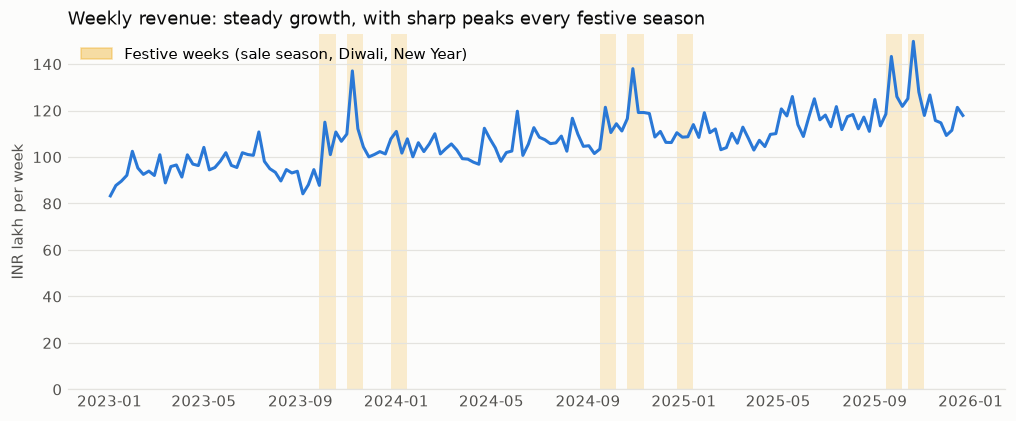

In [4]:
festive = df[HOLIDAYS].any(axis=1)

fig, ax = plt.subplots(figsize=(11, 4.2))
for start in df.loc[festive, config.DATE_COL]:
    ax.axvspan(
        start - WEEK,
        start + 2 * WEEK,
        color=config.COLOR_FESTIVE_SHADE,
        alpha=config.FESTIVE_SHADE_ALPHA,
        linewidth=0,
    )
ax.plot(df[config.DATE_COL], df[config.TARGET_COL] / LAKH, color=config.COLOR_SPEND, linewidth=2)
ax.set_ylim(bottom=0)
ax.set_ylabel("INR lakh per week")
ax.set_title("Weekly revenue: steady growth, with sharp peaks every festive season")
ax.legend(
    handles=[
        Patch(
            color=config.COLOR_FESTIVE_SHADE,
            alpha=0.35,
            label="Festive weeks (sale season, Diwali, New Year)",
        )
    ],
    loc="upper left",
    frameon=False,
)
save(fig, "eda_revenue_over_time")
plt.show()

## 3. Spend by channel over time

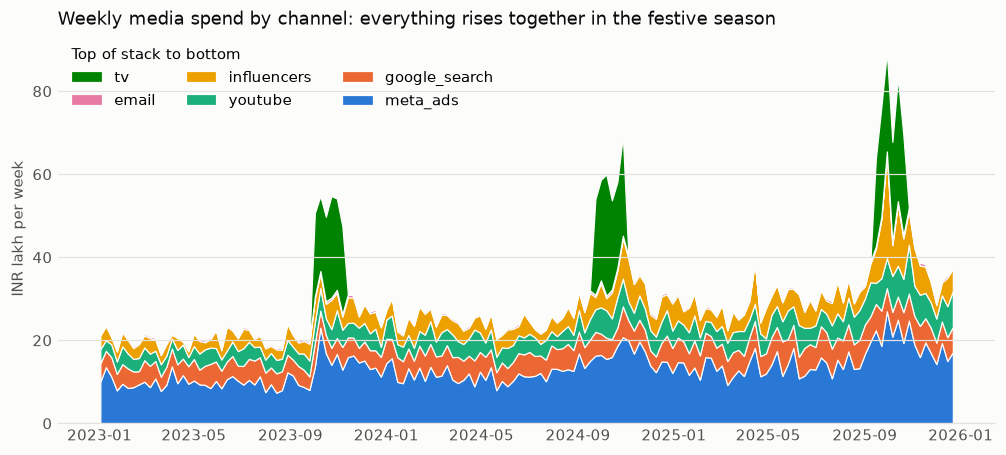

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.stackplot(
    df[config.DATE_COL],
    [df[c] / LAKH for c in SPEND],
    labels=CHANNELS,
    colors=[COLORS[c] for c in CHANNELS],
    edgecolor=config.COLOR_SURFACE,
    linewidth=0.8,
)
ax.set_ylabel("INR lakh per week")
ax.set_title("Weekly media spend by channel: everything rises together in the festive season")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    loc="upper left",
    frameon=False,
    ncols=3,
    title="Top of stack to bottom",
    alignment="left",
)
save(fig, "eda_spend_stacked")
plt.show()

## 4. Correlation: spend vs. revenue

Same-week correlations between revenue and each channel's spend, and between channels.

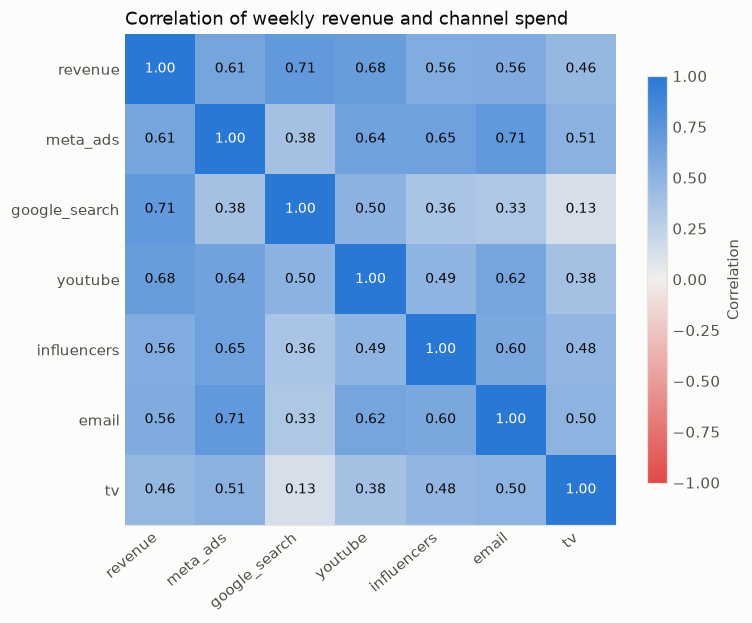

In [6]:
corr = df[[config.TARGET_COL, *SPEND]].rename(columns=channel_name).corr()
cmap = LinearSegmentedColormap.from_list("diverging", config.COLOR_DIVERGING)

fig, ax = plt.subplots(figsize=(7.2, 6))
image = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=40, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if abs(value) > 0.75 else config.COLOR_TEXT,
        )
ax.set_title("Correlation of weekly revenue and channel spend")
fig.colorbar(image, ax=ax, shrink=0.8, label="Correlation")
save(fig, "eda_correlation_heatmap")
plt.show()

## 5. Spend vs. revenue, with lags of 0, 1 and 2 weeks

Each row is a channel; each column compares revenue with that channel's spend the same week,
one week earlier and two weeks earlier. `r` is the correlation.

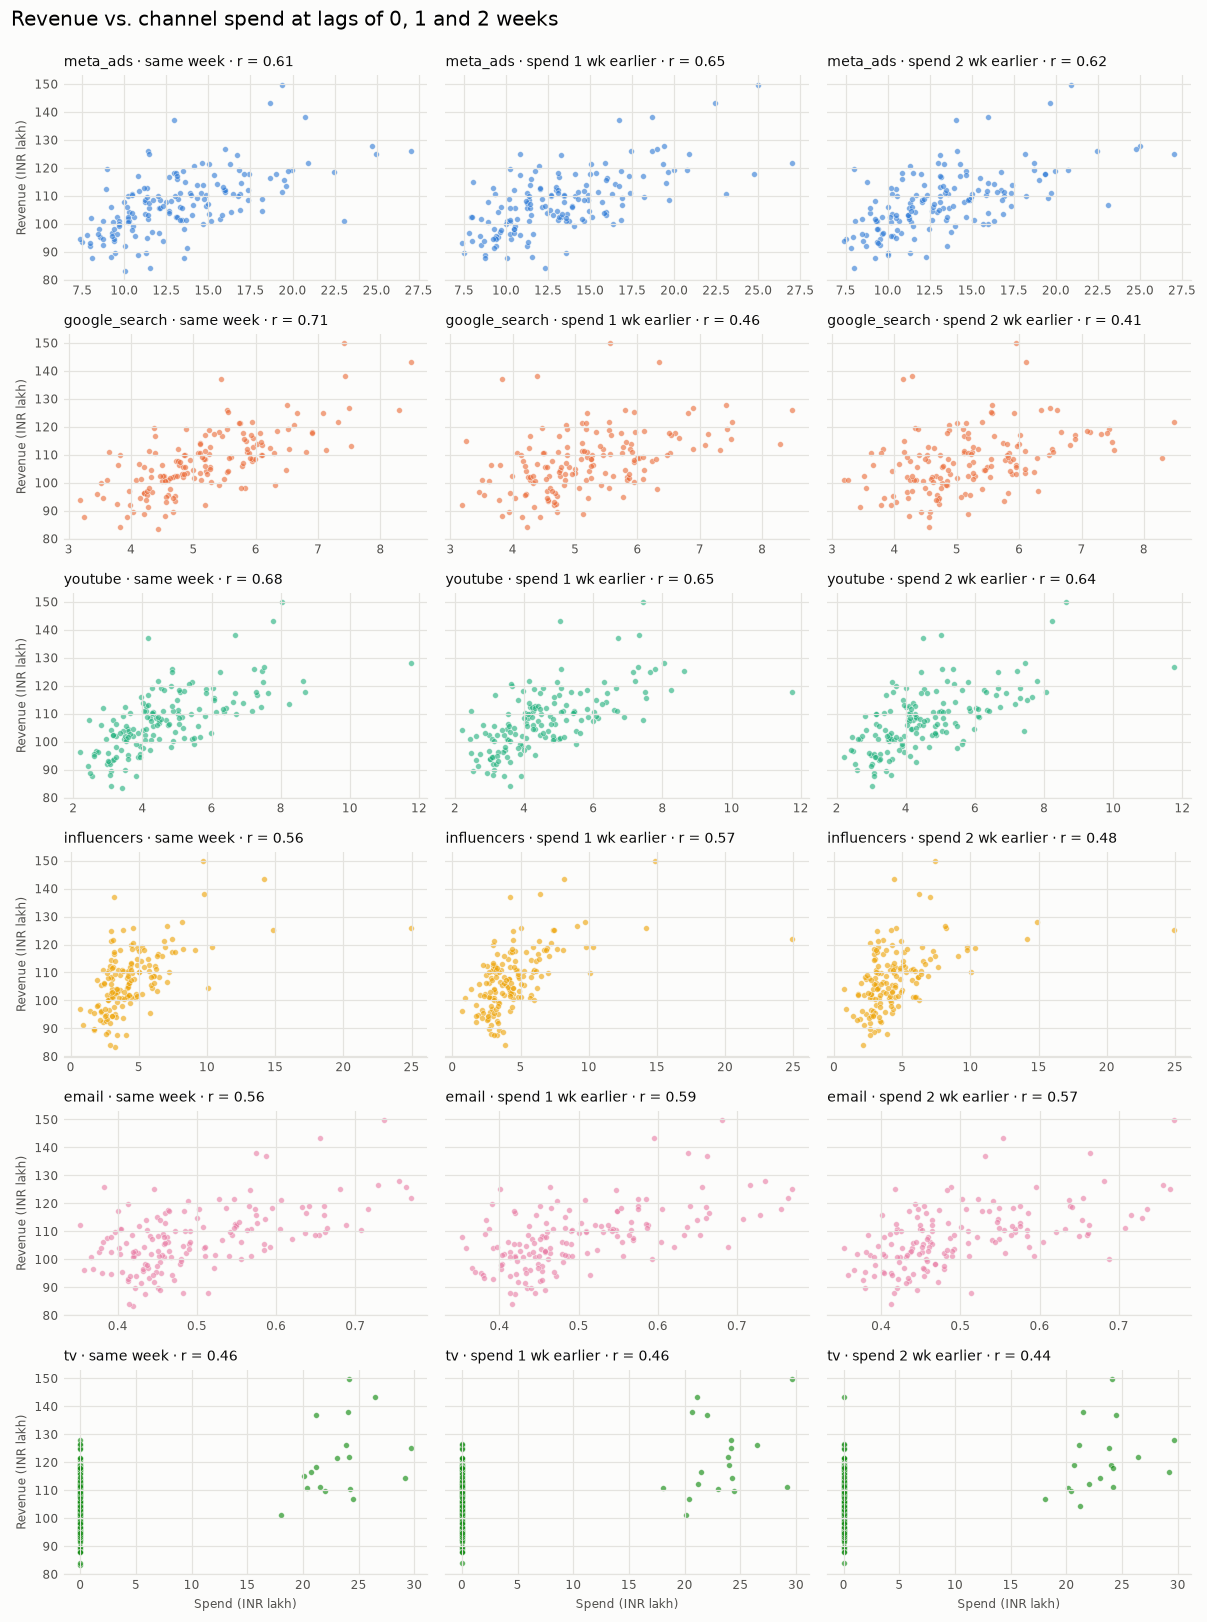

,lag 0,lag 1,lag 2
meta_ads,0.61,0.65,0.62
google_search,0.71,0.46,0.41
youtube,0.68,0.65,0.64
influencers,0.56,0.57,0.48
email,0.56,0.59,0.57
tv,0.46,0.46,0.44


In [7]:
fig, axes = plt.subplots(
    len(CHANNELS), len(config.EDA_LAGS), figsize=(11, 2.5 * len(CHANNELS)), sharey=True
)
lag_corr = pd.DataFrame(
    index=CHANNELS, columns=[f"lag {lag}" for lag in config.EDA_LAGS], dtype=float
)
for row, channel in zip(axes, CHANNELS, strict=True):
    for ax, lag in zip(row, config.EDA_LAGS, strict=True):
        spend = df[f"{config.SPEND_PREFIX}{channel}"].shift(lag)
        r = spend.corr(df[config.TARGET_COL])
        lag_corr.loc[channel, f"lag {lag}"] = r
        ax.scatter(
            spend / LAKH,
            df[config.TARGET_COL] / LAKH,
            s=14,
            color=COLORS[channel],
            alpha=0.6,
            edgecolor=config.COLOR_SURFACE,
            linewidth=0.4,
        )
        ax.grid(True, axis="both")
        ax.set_title(
            f"{channel} · spend {lag} wk earlier · r = {r:.2f}"
            if lag
            else f"{channel} · same week · r = {r:.2f}",
            fontsize=9,
        )
        ax.tick_params(labelsize=8)
    row[0].set_ylabel("Revenue (INR lakh)", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Spend (INR lakh)", fontsize=8)
fig.suptitle(
    "Revenue vs. channel spend at lags of 0, 1 and 2 weeks", x=0.01, ha="left", fontsize=13
)
fig.tight_layout(rect=(0, 0, 1, 0.985))
save(fig, "eda_spend_vs_revenue_lags")
plt.show()

lag_corr.round(2)

## 6. Numbers behind the takeaways

In [8]:
year = df[config.DATE_COL].dt.year
total_spend = df[SPEND].sum(axis=1)
first, last = year.min(), year.max()
active_tv = int((df["spend_tv"] > 0).sum())

facts = {
    "Total revenue (INR crore)": df[config.TARGET_COL].sum() / 1e7,
    "Total media spend (INR crore)": total_spend.sum() / 1e7,
    "Spend as % of revenue": 100 * total_spend.sum() / df[config.TARGET_COL].sum(),
    f"Revenue growth {first} to {last} %": 100
    * (
        df.loc[year == last, config.TARGET_COL].sum()
        / df.loc[year == first, config.TARGET_COL].sum()
        - 1
    ),
    f"Spend growth {first} to {last} %": 100
    * (total_spend[year == last].sum() / total_spend[year == first].sum() - 1),
    "Festive weeks": int(festive.sum()),
    "Revenue lift in festive weeks %": 100
    * (df.loc[festive, config.TARGET_COL].mean() / df.loc[~festive, config.TARGET_COL].mean() - 1),
    "Spend lift in festive weeks %": 100
    * (total_spend[festive].mean() / total_spend[~festive].mean() - 1),
    "Weeks with TV on air": active_tv,
    "Highest channel-to-channel correlation": max(
        v for a, row in report.correlation.items() for b, v in row.items() if a != b
    ),
}
pd.Series(facts).round(2).to_frame("value")

,value
Total revenue (INR crore),167.61
Total media spend (INR crore),47.98
Spend as % of revenue,28.63
Revenue growth 2023 to 2025 %,15.70
Spend growth 2023 to 2025 %,43.03
Festive weeks,8.00
Revenue lift in festive weeks %,20.40
Spend lift in festive weeks %,79.43
Weeks with TV on air,18.00
Highest channel-to-channel correlation,0.71


## 5 things a CMO should know about this data before trusting any model

*Figures below are for the default dataset (`performance_heavy`, seed 42). Re-run the notebook and
update them if the data is regenerated.*

**1. The data is good enough to model, and its weak spots are known.**
Three full years (156 weeks), no gaps, no missing or negative values. The validator scores it
84/100 with no critical issues. No two channels move together closely enough to be
indistinguishable (highest correlation 0.71, against a warning line of 0.80).

**2. Every channel "correlates with revenue", so correlation tells you nothing about which one works.**
All six channels show a 0.46 to 0.71 correlation with revenue. That is mostly because spend and
revenue both grow over time and both peak in the festive season, not because each channel is
equally effective. Ranking channels by this chart would be a mistake.

**3. Search looks like the star, and is the number to trust least at face value.**
Search has the highest same-week correlation with revenue (0.71), but it falls to 0.46 for spend
one week earlier. That is the signature of a channel that *follows* demand: people search when
they already intend to buy. Some of what search appears to drive would have happened anyway.

**4. The festive season is where most of the budget risk sits.**
In the 8 festive weeks, media spend runs about 79% above normal while revenue runs about 20%
above normal. Every channel is turned up at once, and TV is on air only then (18 of 156 weeks,
all in the run-up to Diwali). The data alone cannot cleanly say how much of the festive peak is
the festival, how much is TV, and how much is everything else.

**5. Spend has grown much faster than revenue, and two channels will only ever get a rough answer.**
From 2023 to 2025 media spend rose 43% while revenue rose 16%; media is now about 29% of
revenue. That raises the diminishing-returns question the model exists to answer. Separately,
email is only 1.6% of spend and TV has few active weeks, so expect a wide range on both rather
than a precise ROI. If either decision matters, a holdout or regional test will settle it faster
than more modelling.